In [360]:
""" Imports """
%load_ext autoreload
%autoreload 2

import os
import json
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

import torch
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score

from latent_model.temporal_prediction import create_models_list, create_loaders
from simulation_encoder.models.model_retrieval import load_models

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [361]:
"""Utility Functions"""
def plot_regression_results(y_true, y_pred, label_type):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolor='k')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], color='red', linestyle='--', label="Ideal Fit")
    plt.title(f"Parity Plot for {label_type}")
    plt.xlabel("True Values")
    plt.ylabel("Predicted Values")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

def plot_classification_results(y_true, y_pred, label_type, class_names, save_path=None):
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # normalize by row

    fig, ax = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
    disp.plot(cmap=plt.cm.Blues, colorbar=False, ax=ax, values_format=".2f")

    for text in ax.texts:
        text.set_fontsize(16)

    ax.set_title(label_type, fontsize=20)
    ax.set_xlabel("Predicted label", fontsize=16)
    ax.set_ylabel("True label", fontsize=16)
    ax.tick_params(labelsize=14)

    if save_path:
        plt.savefig(save_path, bbox_inches='tight')
    plt.show()

In [362]:
study_name = "cae-architecture-gastruloid"
results_path = f"results/{study_name}"
data_type = "gastruloid"

In [363]:
if data_type == "arcade":
    seq_len = 15
elif data_type == "gastruloid":
    seq_len = 9
elif data_type == "nasa":
    seq_len = 3
else:
    raise ValueError(f"Unknown data type: {data_type}")
loaders = create_loaders(results_path, seq_len=seq_len)
loaders = dict(sorted(loaders.items()))

temporal_models = defaultdict(lambda: defaultdict(list))
for model_name in os.listdir(results_path):
    model_path = f"{results_path}/{model_name}/_best_model"
    for dataset_name in os.listdir(model_path):
        loader = loaders[model_name][dataset_name]
        num_dims = loader.num_dims
        temporal_models[model_name][dataset_name] = create_models_list(
            input_size=num_dims, output_size=1, classification=True
        )
temporal_models = dict(sorted(temporal_models.items()))

if data_type == "arcade":
    inverse_mapping = {0: "colony", 1: "tissue"}
    cell_context_map = {"C": 0, "CH": 1}
    def transform_sample_id(sample_id):
        return torch.Tensor([cell_context_map[arr.split("_")[0]] for arr in sample_id])
elif data_type == "gastruloid":
    def transform_sample_id(sample_id):
        return torch.Tensor([(int(arr.split("_")[0][-1]) - 1) % 2 for arr in sample_id])
    inverse_mapping = {0: "euploid", 1: "anueploid"}
elif data_type == "nasa":
    radiation_map = {"Fe": 0, "X-ray": 1}
    def transform_sample_id(sample_id):
        return torch.Tensor([radiation_map[arr.split("_")[-1]] for arr in sample_id])
    inverse_mapping = {0: "Fe", 1: "X-ray"}


In [364]:
patience = 5 
max_epochs = 50
best_models = defaultdict(lambda: defaultdict(list))

for model_name, dataset in temporal_models.items():
    for dataset_name, models in dataset.items():
        
        loader = loaders[model_name][dataset_name]
        train_loader = loader.get_dataloader("train")
        val_loader = loader.get_dataloader("val")
        test_loader = loader.get_dataloader("test")

        all_train_embeddings = []
        for embeddings, _ in train_loader:
            all_train_embeddings.append(embeddings)

        all_train_embeddings = torch.cat(all_train_embeddings, dim=0)
        mean = all_train_embeddings.mean(dim=0, keepdim=True)
        std = all_train_embeddings.std(dim=0, keepdim=True) + 1e-8

        for model in models:
            best_model = None
            best_loss = float("inf")
            no_improvement_count = 0

            model.train()
            for epoch in range(max_epochs):
                epoch_loss = 0.0
                for embeddings, sample_id in train_loader:
                    x_batch = (embeddings - mean) / std
                    y_batch = transform_sample_id(sample_id)
                    model.optimizer.zero_grad()
                    y_pred = model(x_batch)
                    loss = model.criterion(y_pred.flatten(), y_batch)
                    loss.backward()
                    model.optimizer.step()
                    epoch_loss += loss.item()
                epoch_loss /= len(train_loader)

                model.eval()
                val_loss = 0.0
                with torch.no_grad():
                    for embeddings, sample_id in val_loader:
                        x_batch = (embeddings - mean) / std
                        y_batch = transform_sample_id(sample_id)
                        y_pred = model(x_batch)
                        val_loss += model.criterion(y_pred.flatten(), y_batch).item()

                val_loss /= len(val_loader)

                if val_loss < best_loss:
                    best_loss = val_loss
                    best_model = model
                    no_improvement_count = 0
                else:
                    no_improvement_count += 1

                if no_improvement_count >= patience:
                    break
            print(f"{model_name} trained for {epoch} epochs")
            best_models[model_name][dataset_name] = best_model
print("Training complete")
print(f"Training samples: {len(train_loader.dataset)}")
print(f"Validation samples: {len(val_loader.dataset)}")
print(f"Testing samples: {len(test_loader.dataset)}")

cae-medium trained for 12 epochs
cae-medium trained for 12 epochs
cae-medium trained for 9 epochs
cae-medium trained for 10 epochs
cae-medium trained for 9 epochs
cae-medium trained for 11 epochs
cae-medium trained for 9 epochs
cae-medium trained for 10 epochs
cae-medium trained for 10 epochs
cae-small trained for 20 epochs
cae-small trained for 16 epochs
cae-small trained for 13 epochs
cae-small trained for 11 epochs
cae-small trained for 10 epochs
cae-small trained for 12 epochs
cae-small trained for 9 epochs
cae-small trained for 12 epochs
cae-small trained for 13 epochs
Training complete
Training samples: 669
Validation samples: 168
Testing samples: 210


--------- Training ------------
              precision    recall  f1-score   support

   anueploid       0.80      0.64      0.71       343
     euploid       0.69      0.83      0.75       326

    accuracy                           0.74       669
   macro avg       0.75      0.74      0.73       669
weighted avg       0.75      0.74      0.73       669



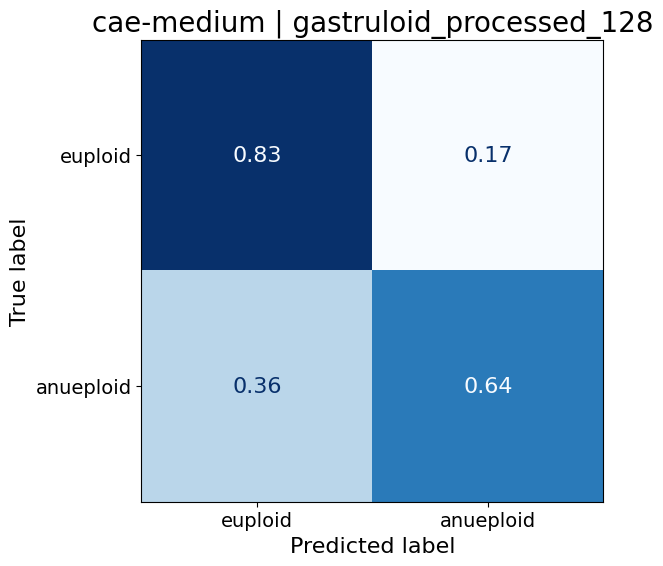

--------- Test ------------
              precision    recall  f1-score   support

   anueploid       0.72      0.60      0.66        98
     euploid       0.70      0.79      0.74       112

    accuracy                           0.70       210
   macro avg       0.71      0.70      0.70       210
weighted avg       0.71      0.70      0.70       210



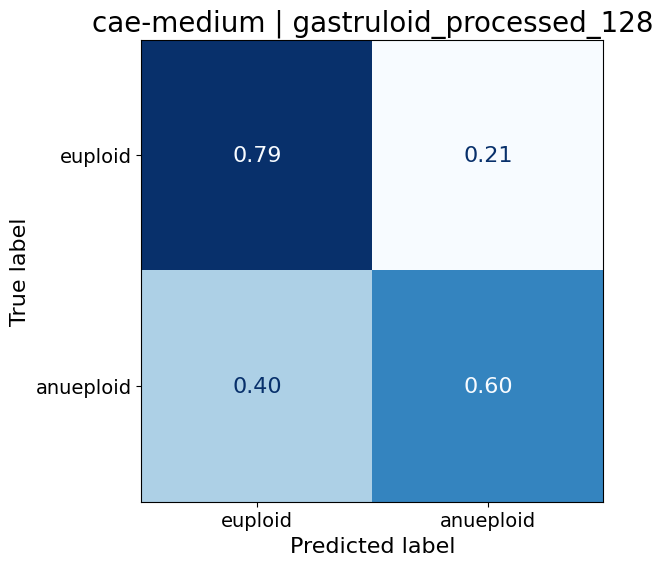

--------- Training ------------
              precision    recall  f1-score   support

   anueploid       0.96      0.91      0.93       343
     euploid       0.91      0.96      0.93       326

    accuracy                           0.93       669
   macro avg       0.93      0.93      0.93       669
weighted avg       0.93      0.93      0.93       669



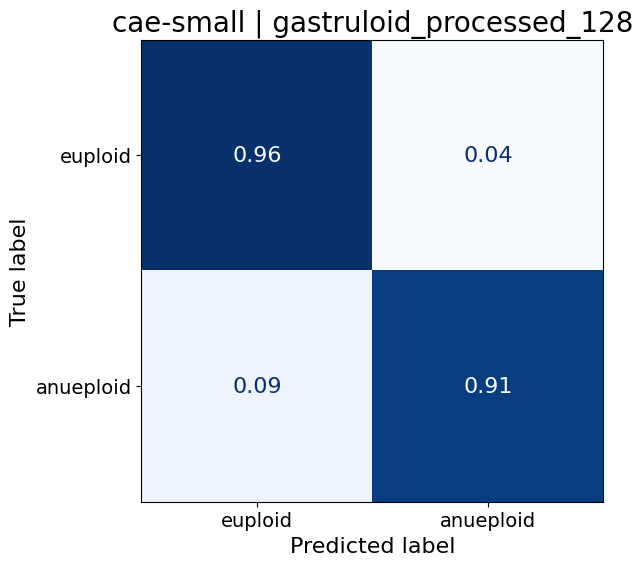

--------- Test ------------
              precision    recall  f1-score   support

   anueploid       0.68      0.62      0.65        98
     euploid       0.69      0.74      0.72       112

    accuracy                           0.69       210
   macro avg       0.68      0.68      0.68       210
weighted avg       0.69      0.69      0.68       210



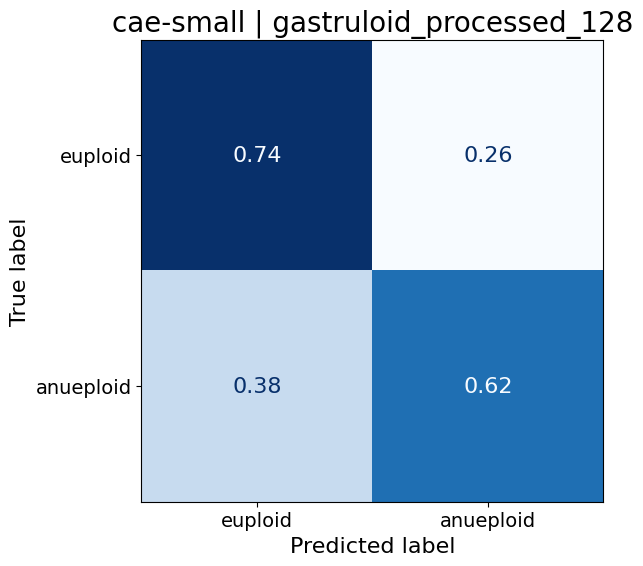

In [365]:
for model_name, dataset in best_models.items():
    for dataset_name, model in dataset.items():
        loader = loaders[model_name][dataset_name]
        train_loader = loader.get_dataloader("train")
        val_loader = loader.get_dataloader("val")
        test_loader = loader.get_dataloader("test")

        y_true_labels = []
        y_pred_labels = []
        sample_id_list = []
        
        model.eval()
        with torch.no_grad():
            for embeddings, sample_id in train_loader:
                x_batch = (embeddings - mean) / std
                y_batch = transform_sample_id(sample_id)
                y_pred = model(x_batch)

                y_true_labels.extend(y_batch.numpy())
                y_pred_labels.extend(y_pred.flatten().numpy())
                sample_id_list.extend(sample_id)
                
        y_pred_labels = [int(label > 0.5) for label in y_pred_labels]
        class_names = inverse_mapping.values()
        y_test_original = [inverse_mapping[label] for label in y_true_labels]
        y_pred_original = [inverse_mapping[label] for label in y_pred_labels]

        print("--------- Training ------------")
        print(classification_report(y_test_original, y_pred_original, zero_division=0))
        save_path = f"figures/plots/cm_{model_name}_train.png"
        plot_classification_results(y_true_labels, y_pred_labels, f"{model_name} | {dataset_name}", class_names, save_path)

        y_true_labels = []
        y_pred_labels = []
        sample_id_list = []
        
        model.eval()
        with torch.no_grad():
            for embeddings, sample_id in test_loader:
                x_batch = (embeddings - mean) / std
                y_batch = transform_sample_id(sample_id)
                y_pred = model(x_batch)

                y_true_labels.extend(y_batch.numpy())
                y_pred_labels.extend(y_pred.flatten().numpy())
                sample_id_list.extend(sample_id)
                
        y_pred_labels = [int(label > 0.5) for label in y_pred_labels]
        class_names = inverse_mapping.values()
        y_test_original = [inverse_mapping[label] for label in y_true_labels]
        y_pred_original = [inverse_mapping[label] for label in y_pred_labels]

        print("--------- Test ------------")
        print(classification_report(y_test_original, y_pred_original, zero_division=0))
        save_path = f"figures/plots/cm_{model_name}_test.png"
        plot_classification_results(y_true_labels, y_pred_labels, f"{model_name} | {dataset_name}", class_names, save_path)

In [366]:
all_results_data = {
    "study_name": study_name,
    "model_dataset_results": []
}

for model_name, dataset in best_models.items():
    for dataset_name, model in dataset.items():
        loader = loaders[model_name][dataset_name]
        train_loader = loader.get_dataloader("train")
        val_loader = loader.get_dataloader("val")
        test_loader = loader.get_dataloader("test")
        

        model.eval()
        correct = []
        incorrect = []
        for loader in [train_loader, val_loader, test_loader]:
            y_true_labels = []
            y_pred_labels = []
            sample_id_list = []

            with torch.no_grad():
                for embeddings, sample_id in loader:
                    x_batch = embeddings
                    y_batch = transform_sample_id(sample_id)
                    y_pred = model(x_batch)

                    y_true_labels.extend(y_batch.numpy())
                    y_pred_labels.extend(y_pred.flatten().numpy())
                    sample_id_list.extend(sample_id)

            y_pred_labels = [int(label > 0.5) for label in y_pred_labels]
            y_true_original = [inverse_mapping[label] for label in y_true_labels]
            y_pred_original = [inverse_mapping[label] for label in y_pred_labels]

            correct.extend([sid for sid, yt, yp in zip(sample_id_list, y_true_original, y_pred_original) if yt == yp])
            incorrect.extend([sid for sid, yt, yp in zip(sample_id_list, y_true_original, y_pred_original) if yt != yp])

        current_model_dataset_results = {
            "model_name": model_name,
            "dataset_name": dataset_name,
            "total_correct": len(correct),
            "total_incorrect": len(incorrect),
            "correct_predictions": correct,
            "incorrect_predictions": incorrect
        }

        all_results_data["model_dataset_results"].append(current_model_dataset_results)

json_filename = f"results_downstream/{study_name}_classification_results.json"
with open(json_filename, 'w') as f:
    json.dump(all_results_data, f, indent=4)

In [367]:
def permutation_importance_aggregated(model, test_loader, transform_sample_id, baseline_score, num_iterations=10):
    model.eval()
    num_features = next(iter(test_loader))[0].shape[-1]
    importance_scores = np.zeros(num_features)

    for _ in range(num_iterations):
        iteration_importance = []
        for feature_idx in range(num_features):
            y_pred_permuted = []
            y_true = []

            with torch.no_grad():
                for embeddings, sample_id in test_loader:
                    permuted_embeddings = embeddings.clone()
                    permuted_embeddings[:, :, feature_idx] = permuted_embeddings[:, torch.randperm(permuted_embeddings.size(1)), feature_idx]

                    y_batch = transform_sample_id(sample_id)
                    y_pred = model(permuted_embeddings)

                    y_true.extend(y_batch.numpy())
                    y_pred_permuted.extend((y_pred.flatten().numpy() > 0.5).astype(int))

            permuted_score = accuracy_score(y_true, y_pred_permuted)
            importance = baseline_score - permuted_score
            iteration_importance.append(importance)

        importance_scores += np.array(iteration_importance)

    importance_scores /= num_iterations
    feature_importance = sorted(enumerate(importance_scores), key=lambda x: x[1], reverse=True)
    return feature_importance

def visualize_feature_tuning(model, latent_sample, feature_idx, variation_range=(-3, 3), steps=7):
    half_steps = steps // 2
    feature_values = torch.linspace(variation_range[0], variation_range[1], steps)

    fig, axes = plt.subplots(len(latent_sample), steps, figsize=(3 * steps, 3 * len(latent_sample)))
    if len(latent_sample) == 1:
        axes = axes[None, :]

    for row, latent_vector in enumerate(latent_sample):
        with torch.no_grad():
            original_image = model.decode_image(latent_vector.unsqueeze(0)).squeeze().detach().cpu().numpy()

        for col, val in enumerate(feature_values):
            modified_latent = latent_vector.clone()

            if col == half_steps:
                image_to_plot = original_image
                title = "Original"
                cmap = 'gray'
                vmin = vmax = None
            else:
                modified_latent[feature_idx] += val
                with torch.no_grad():
                    modified_image = model.decode_image(modified_latent.unsqueeze(0)).squeeze().detach().cpu().numpy()
                diff_image = modified_image - original_image
                image_to_plot = diff_image
                title = f"{val.item():+.2f}"
                cmap = 'RdBu'
                vmax = np.max(np.abs(diff_image))
                vmin = -vmax

            axes[row, col].imshow(image_to_plot, cmap=cmap, vmin=vmin, vmax=vmax)
            axes[row, col].set_title(title)
            axes[row, col].axis('off')

    fig.savefig(f"figures/feature_tuning_{model.name}_{latent_sample.size(1)}-{feature_idx}.png", dpi=300, bbox_inches='tight')
    plt.tight_layout()
    plt.show()

In [368]:
num_iterations = 25
top_features = defaultdict(lambda: defaultdict(list))
for model_name, dataset in best_models.items():
    top_features[model_name] = {}
    for dataset_name, model in dataset.items():
        loader = loaders[model_name][dataset_name]
        train_loader = loader.get_dataloader("train")
        val_loader = loader.get_dataloader("val")
        test_loader = loader.get_dataloader("test")
        y_true_labels, y_pred_labels = [], []

        model.eval()
        with torch.no_grad():
            for embeddings, sample_id in test_loader:
                x_batch = embeddings
                y_batch = transform_sample_id(sample_id)
                y_pred = model(x_batch)

                y_true_labels.extend(y_batch.numpy())
                y_pred_labels.extend((y_pred.flatten().numpy() > 0.5).astype(int))

        baseline_acc = accuracy_score(y_true_labels, y_pred_labels)
        print(f"\nBaseline Accuracy for {model_name} | {dataset_name}: {baseline_acc:.4f}")

        feature_importances = permutation_importance_aggregated(
            model, test_loader, transform_sample_id, baseline_acc, num_iterations=num_iterations
        )
        top_features[model_name][dataset_name] = feature_importances
        print(f"Average FI for classificaiton (over {num_iterations} iterations):")
        for idx, imp in feature_importances:
            print(f"  Latent dimension {idx}: importance = {imp:.4f}")


Baseline Accuracy for cae-medium | gastruloid_processed_128: 0.7095
Average FI for classificaiton (over 25 iterations):
  Latent dimension 3: importance = 0.0034
  Latent dimension 14: importance = 0.0029
  Latent dimension 7: importance = 0.0019
  Latent dimension 5: importance = 0.0015
  Latent dimension 12: importance = 0.0008
  Latent dimension 13: importance = -0.0008
  Latent dimension 6: importance = -0.0019
  Latent dimension 10: importance = -0.0051
  Latent dimension 4: importance = -0.0051
  Latent dimension 11: importance = -0.0076
  Latent dimension 1: importance = -0.0088
  Latent dimension 15: importance = -0.0091
  Latent dimension 8: importance = -0.0091
  Latent dimension 0: importance = -0.0095
  Latent dimension 9: importance = -0.0130
  Latent dimension 2: importance = -0.0141

Baseline Accuracy for cae-small | gastruloid_processed_128: 0.7143
Average FI for classificaiton (over 25 iterations):
  Latent dimension 14: importance = 0.0257
  Latent dimension 7: impor

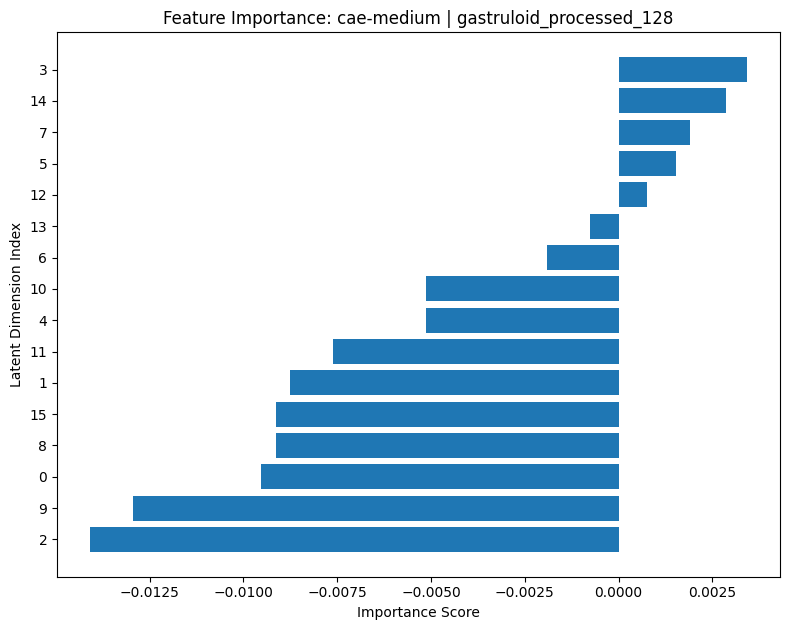

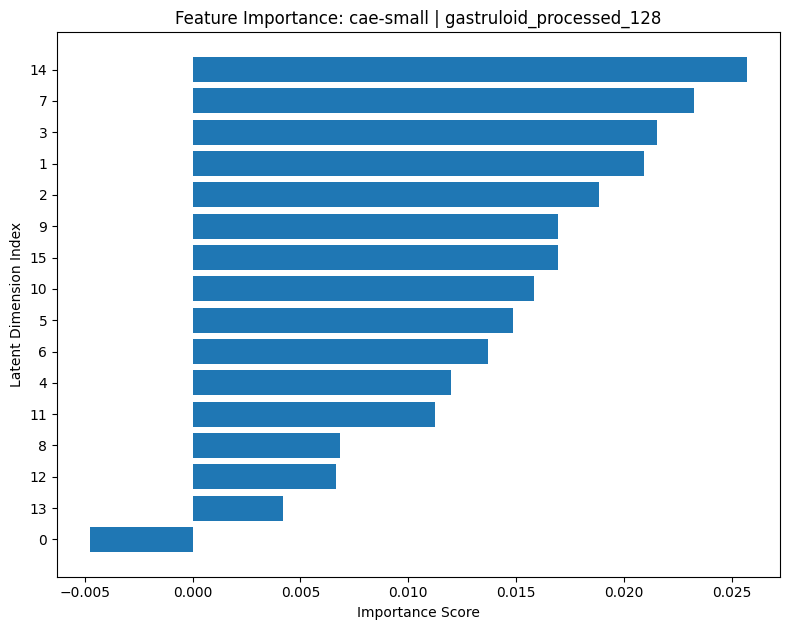

In [369]:
for model_name, dataset_importances in top_features.items():
    for dataset_name, importances in dataset_importances.items():
        sorted_importances = sorted(importances, key=lambda x: x[1], reverse=True)
        feature_indices, importance_values = zip(*sorted_importances)

        plt.figure(figsize=(8, len(feature_indices) * 0.4))
        plt.barh(range(len(feature_indices)), importance_values, tick_label=feature_indices)
        plt.xlabel("Importance Score")
        plt.ylabel("Latent Dimension Index")
        plt.title(f"Feature Importance: {model_name} | {dataset_name}")
        plt.gca().invert_yaxis()  # most important on top
        plt.tight_layout()
        plt.show()

In [370]:
import random

autoencoders = load_models(results_path, num_timepoints=seq_len, best_models_flag=True)
autoencoders = dict(sorted(autoencoders.items()))

index = None
random_samples = defaultdict(lambda: defaultdict(list))
for model_name, dataset in autoencoders.items():
    for dataset_name, encoder_model in dataset.items():
        loader = loaders[model_name][dataset_name]
        test_loader = loader.get_dataloader('test')
        dataset = test_loader.dataset
        if not index:
            index = random.randint(0, len(dataset) - 1)
        latent_sample, sample_id = dataset[idx]
        latent_sample = latent_sample[-1].unsqueeze(0)
        random_samples[model_name][dataset_name] = latent_sample
                

Loading model cae_medium (8.70e+06 parameters)
Loading model cae_small (3.38e+07 parameters)


Model: cae-medium Most important feature: 3


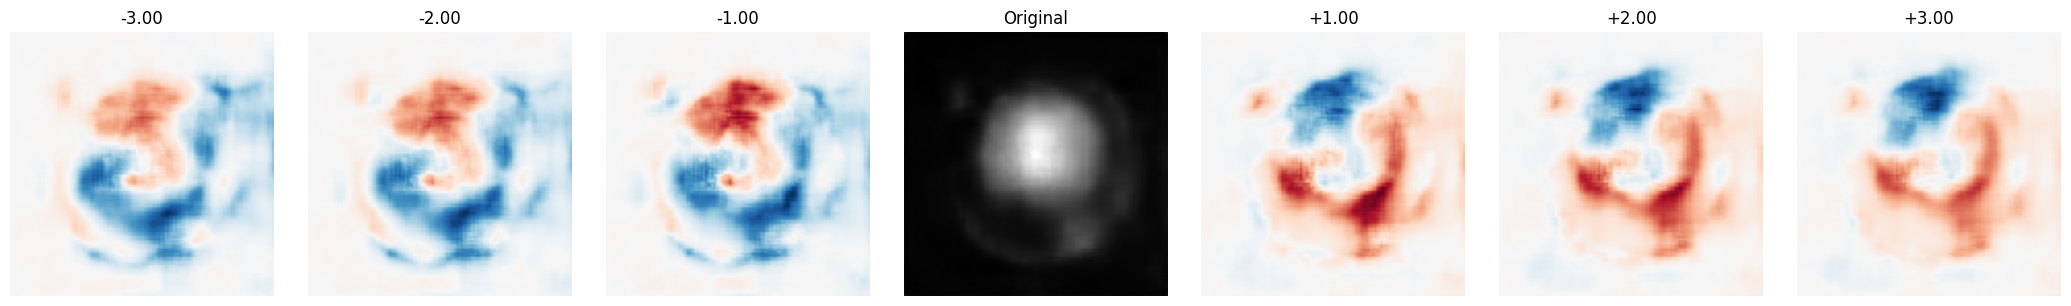

Model: cae-small Most important feature: 14


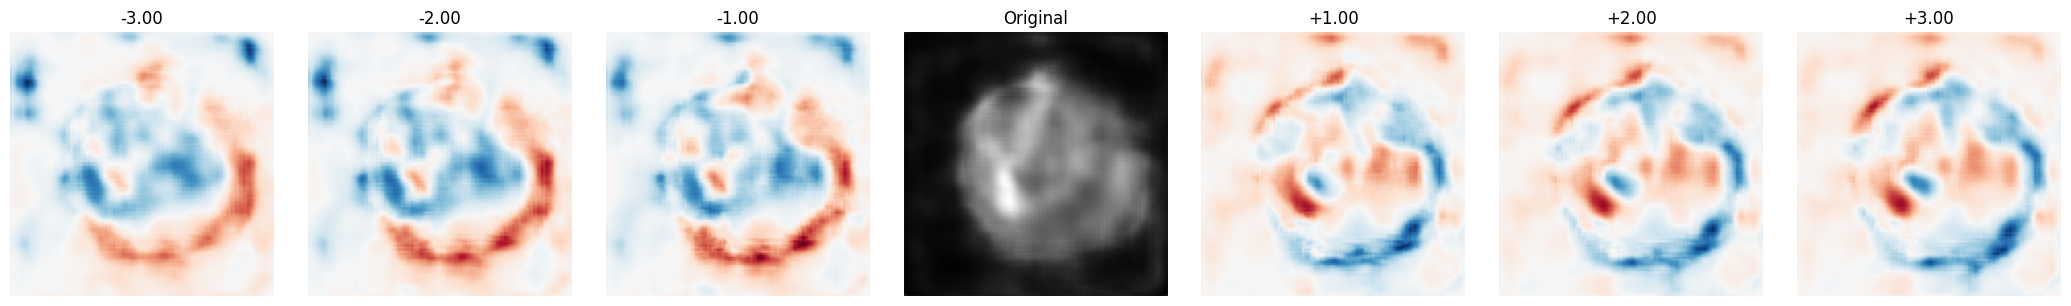

In [371]:
for model_name, dataset in autoencoders.items():
    for dataset_name, encoder_model in dataset.items():
        most_important_features = top_features[model_name][dataset_name][0][0]
        print(f"Model: {model_name} Most important feature: {most_important_features}")
        latent_sample = random_samples[model_name][dataset_name]
        encoder_model.eval()
        with torch.no_grad():
            visualize_feature_tuning(
                encoder_model, latent_sample, feature_idx=most_important_features, variation_range=(-3, 3), steps=7
            )